In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

In [2]:
# Paths
CLEAN_CSV   = Path("../data/processed/tabular_data/angles_dataset_clean.csv")
OUTPUT_DIR  = Path("../data/processed/tabular_data")
SCALER_PATH = Path("../data/models/scaler.pkl")
OUTPUT_DIR.parent.mkdir(parents=True, exist_ok=True)

# Load
df = pd.read_csv(CLEAN_CSV)

print("✅ Cleaned dataset loaded.")
print(f"   Shape   : {df.shape}")
print(f"   Columns : {list(df.columns)}")
display(df.head())

✅ Cleaned dataset loaded.
   Shape   : (19349, 32)
   Columns : ['video_id', 'frame_number', 'left_elbow_angle', 'right_elbow_angle', 'left_shoulder_angle', 'right_shoulder_angle', 'left_hip_angle', 'right_hip_angle', 'left_knee_angle', 'right_knee_angle', 'left_ankle_angle', 'right_ankle_angle', 'shoulder_z_diff', 'hip_z_diff', 'torso_rotation', 'left_elbow_angle_velocity', 'right_elbow_angle_velocity', 'left_shoulder_angle_velocity', 'right_shoulder_angle_velocity', 'left_hip_angle_velocity', 'right_hip_angle_velocity', 'left_knee_angle_velocity', 'right_knee_angle_velocity', 'left_ankle_angle_velocity', 'right_ankle_angle_velocity', 'shoulder_z_diff_velocity', 'hip_z_diff_velocity', 'torso_rotation_velocity', 'exercise_name', 'exercise_correctness', 'exercise_name_encoded', 'exercise_correctness_encoded']


,video_id,frame_number,left_elbow_angle,right_elbow_angle,left_shoulder_angle,right_shoulder_angle,left_hip_angle,right_hip_angle,left_knee_angle,right_knee_angle,...,right_knee_angle_velocity,left_ankle_angle_velocity,right_ankle_angle_velocity,shoulder_z_diff_velocity,hip_z_diff_velocity,torso_rotation_velocity,exercise_name,exercise_correctness,exercise_name_encoded,exercise_correctness_encoded
0,0,0,123.53,133.99,138.99,150.05,163.41,171.58,168.98,172.80,...,0.0,0.0,0.0,0.00,0.00,0.00,pullup,correct,0,1
1,0,1,118.37,131.03,136.90,149.61,164.01,171.91,166.61,173.30,...,15.0,153.3,146.1,3.18,2.29,0.89,pullup,correct,0,1
2,0,2,109.80,125.55,132.95,145.87,164.80,171.25,166.04,172.26,...,31.2,213.0,75.3,2.86,1.71,1.15,pullup,correct,0,1
3,0,3,104.63,121.92,129.91,143.21,165.99,171.22,166.99,172.69,...,12.9,106.8,1.2,0.87,0.56,0.31,pullup,correct,0,1
4,0,4,96.85,110.27,125.62,136.50,166.72,171.62,167.40,172.93,...,7.2,53.1,8.1,0.38,0.41,0.03,pullup,correct,0,1


In [3]:
# Columns that are not features
NON_FEATURE_COLS = [
    "video_id",
    "frame_number",
    "exercise_name",
    "exercise_correctness",
    "exercise_name_encoded",
    "exercise_correctness_encoded"
]

# Features
feature_cols = [col for col in df.columns if col not in NON_FEATURE_COLS]

# Labels
X = df[feature_cols]
y_exercise    = df["exercise_name_encoded"]         # 4 classes: pullup, pushup, russian_twist, squat
y_correctness = df["exercise_correctness_encoded"]  # binary: 1=correct, 0=incorrect

print(f"✅ Features selected: {len(feature_cols)} columns")
print(f"   Feature columns : {feature_cols}")
print(f"\n   Exercise label distribution:\n{y_exercise.value_counts()}")
print(f"\n   Correctness label distribution:\n{y_correctness.value_counts()}")

✅ Features selected: 26 columns
   Feature columns : ['left_elbow_angle', 'right_elbow_angle', 'left_shoulder_angle', 'right_shoulder_angle', 'left_hip_angle', 'right_hip_angle', 'left_knee_angle', 'right_knee_angle', 'left_ankle_angle', 'right_ankle_angle', 'shoulder_z_diff', 'hip_z_diff', 'torso_rotation', 'left_elbow_angle_velocity', 'right_elbow_angle_velocity', 'left_shoulder_angle_velocity', 'right_shoulder_angle_velocity', 'left_hip_angle_velocity', 'right_hip_angle_velocity', 'left_knee_angle_velocity', 'right_knee_angle_velocity', 'left_ankle_angle_velocity', 'right_ankle_angle_velocity', 'shoulder_z_diff_velocity', 'hip_z_diff_velocity', 'torso_rotation_velocity']

   Exercise label distribution:
exercise_name_encoded
2    6097
0    4589
3    4345
1    4318
Name: count, dtype: int64

   Correctness label distribution:
exercise_correctness_encoded
1    10062
0     9287
Name: count, dtype: int64


In [4]:
# ── Video-level stratified split (fixes frame leakage) ───────────────────────
# Get one representative row per video (its exercise label)
video_meta = df.groupby("video_id")["exercise_name_encoded"].first().reset_index()

# 70% train / 30% temp  — stratified by exercise class
train_ids, temp_ids = train_test_split(
    video_meta["video_id"],
    test_size=0.30,
    stratify=video_meta["exercise_name_encoded"],
    random_state=42
)

# 15% val / 15% test  — from the 30% temp
temp_meta = video_meta[video_meta["video_id"].isin(temp_ids)]
val_ids, test_ids = train_test_split(
    temp_meta["video_id"],
    test_size=0.50,
    stratify=temp_meta["exercise_name_encoded"],
    random_state=42
)

# Assign all frames from each video to the correct split
train_df = df[df["video_id"].isin(train_ids)]
val_df   = df[df["video_id"].isin(val_ids)]
test_df  = df[df["video_id"].isin(test_ids)]

# Extract features and labels
X_train = train_df[feature_cols]
X_val   = val_df[feature_cols]
X_test  = test_df[feature_cols]

y_ex_train  = train_df["exercise_name_encoded"].reset_index(drop=True)
y_ex_val    = val_df["exercise_name_encoded"].reset_index(drop=True)
y_ex_test   = test_df["exercise_name_encoded"].reset_index(drop=True)

y_cor_train = train_df["exercise_correctness_encoded"].reset_index(drop=True)
y_cor_val   = val_df["exercise_correctness_encoded"].reset_index(drop=True)
y_cor_test  = test_df["exercise_correctness_encoded"].reset_index(drop=True)

print("✅ Video-level split complete — no frame leakage.")
print(f"   Train : {train_df['video_id'].nunique()} videos → {len(X_train)} frames ({len(X_train)/len(df)*100:.1f}%)")
print(f"   Val   : {val_df['video_id'].nunique()} videos → {len(X_val)} frames ({len(X_val)/len(df)*100:.1f}%)")
print(f"   Test  : {test_df['video_id'].nunique()} videos → {len(X_test)} frames ({len(X_test)/len(df)*100:.1f}%)")

# Sanity check — no class should be 0 in any split
print("\n📊 Frame distribution per split (exercise × correctness):")
for name, sdf in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"\n{name}:")
    print(sdf.groupby(["exercise_name_encoded", "exercise_correctness_encoded"]).size().unstack(fill_value=0))

✅ Video-level split complete — no frame leakage.
   Train : 55 videos → 13480 frames (69.7%)
   Val   : 12 videos → 3724 frames (19.2%)
   Test  : 12 videos → 2145 frames (11.1%)

📊 Frame distribution per split (exercise × correctness):

Train:
exercise_correctness_encoded     0     1
exercise_name_encoded                   
0                             1398  1780
1                             1586  1453
2                             2071  2095
3                             1238  1859

Val:
exercise_correctness_encoded    0    1
exercise_name_encoded                 
0                             687  236
1                             353  379
2                             784  529
3                             624  132

Test:
exercise_correctness_encoded    0    1
exercise_name_encoded                 
0                               0  488
1                             117  430
2                             166  452
3                             263  229


In [5]:
# Fit ONLY on training data to avoid data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrames to preserve column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_val_scaled   = pd.DataFrame(X_val_scaled,   columns=feature_cols)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=feature_cols)

# Save the scaler for use in the inference pipeline later
joblib.dump(scaler, SCALER_PATH)

print("✅ Scaler fitted on training data and saved.")
print(f"   Saved to : {SCALER_PATH}")
print(f"\n   Training data mean (first 3 features)  : {scaler.mean_[:3].round(4)}")
print(f"   Training data scale (first 3 features) : {scaler.scale_[:3].round(4)}")

✅ Scaler fitted on training data and saved.
   Saved to : ..\data\models\scaler.pkl

   Training data mean (first 3 features)  : [108.7425 104.3894  64.7887]
   Training data scale (first 3 features) : [49.4359 53.5363 49.3485]


In [6]:
# Reconstruct full splits (scaled features + both labels)
def save_split(X_scaled, y_exercise, y_correctness, split_name):
    split_df = X_scaled.copy()
    split_df["exercise_name_encoded"]      = y_exercise.values
    split_df["exercise_correctness_encoded"] = y_correctness.values
    path = OUTPUT_DIR / f"{split_name}.csv"
    split_df.to_csv(path, index=False)
    print(f"   ✅ {split_name}.csv saved → {split_df.shape[0]} rows, {split_df.shape[1]} columns")

print("💾 Saving splits...")
save_split(X_train_scaled, y_ex_train, y_cor_train, "train")
save_split(X_val_scaled,   y_ex_val,   y_cor_val,   "val")
save_split(X_test_scaled,  y_ex_test,  y_cor_test,  "test")

print(f"\n✅ All splits saved to: {OUTPUT_DIR}")

💾 Saving splits...
   ✅ train.csv saved → 13480 rows, 28 columns
   ✅ val.csv saved → 3724 rows, 28 columns
   ✅ test.csv saved → 2145 rows, 28 columns

✅ All splits saved to: ..\data\processed\tabular_data


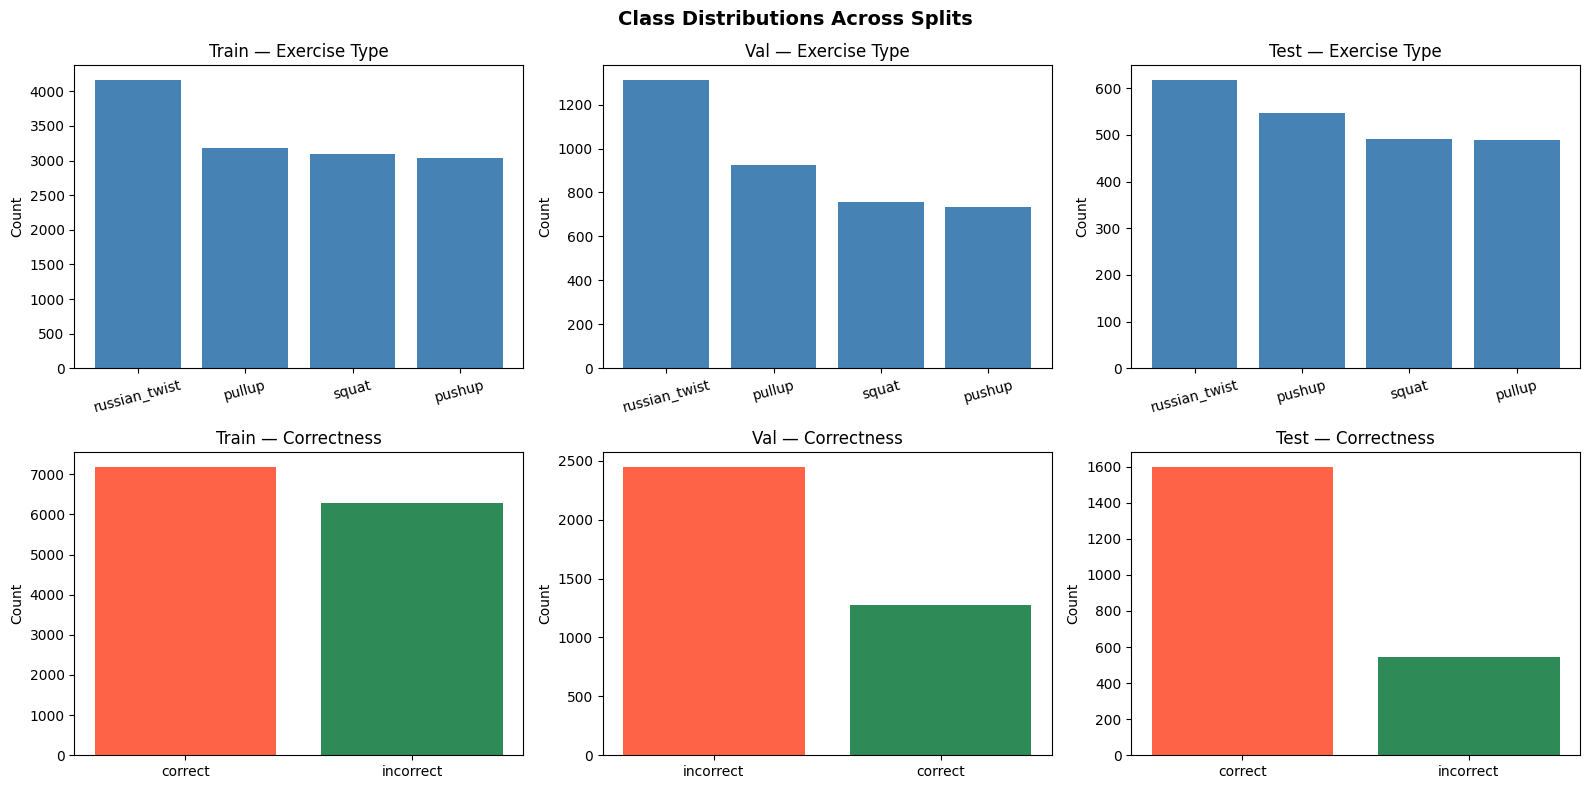

✅ Distribution plot saved.


In [7]:
exercise_map   = {0: "pullup", 1: "pushup", 2: "russian_twist", 3: "squat"}
correctness_map = {0: "incorrect", 1: "correct"}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Class Distributions Across Splits", fontsize=14, fontweight="bold")

splits = {
    "Train": (y_ex_train, y_cor_train),
    "Val"  : (y_ex_val,   y_cor_val),
    "Test" : (y_ex_test,  y_cor_test)
}

for col, (split_name, (y_ex, y_cor)) in enumerate(splits.items()):

    # Exercise distribution
    ex_counts = y_ex.map(exercise_map).value_counts()
    axes[0, col].bar(ex_counts.index, ex_counts.values, color="steelblue")
    axes[0, col].set_title(f"{split_name} — Exercise Type")
    axes[0, col].set_ylabel("Count")
    axes[0, col].tick_params(axis="x", rotation=15)

    # Correctness distribution
    cor_counts = y_cor.map(correctness_map).value_counts()
    axes[1, col].bar(cor_counts.index, cor_counts.values, color=["tomato", "seagreen"])
    axes[1, col].set_title(f"{split_name} — Correctness")
    axes[1, col].set_ylabel("Count")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "split_distributions.png", dpi=150)
plt.show()
print("✅ Distribution plot saved.")

In [8]:
print("=" * 55)
print("        02_data_preparation.ipynb — SUMMARY")
print("=" * 55)

print(f"\n📂 Input  : {CLEAN_CSV}")
print(f"📂 Output : {OUTPUT_DIR}")
print(f"📂 Scaler : {SCALER_PATH}")

print(f"\n📊 Dataset split (70/15/15):")
print(f"   Train : {X_train_scaled.shape[0]} rows")
print(f"   Val   : {X_val_scaled.shape[0]} rows")
print(f"   Test  : {X_test_scaled.shape[0]} rows")

print(f"\n🔢 Features : {len(feature_cols)} columns")
print(f"   {feature_cols}")

print(f"\n🏷️  Labels:")
print(f"   exercise_name_encoded      → {sorted(y_exercise.unique())} ({[exercise_map[i] for i in sorted(y_exercise.unique())]})")
print(f"   exercise_correctness_encoded → 0=incorrect, 1=correct")

print(f"\n✅ Files saved:")
print(f"   train.csv, val.csv, test.csv  → {OUTPUT_DIR}")
print(f"   scaler.pkl                    → {SCALER_PATH}")
print(f"   split_distributions.png       → {OUTPUT_DIR}")

print("\n" + "=" * 55)
print("  ✅ 02_data_preparation.ipynb COMPLETE")
print("=" * 55)

        02_data_preparation.ipynb — SUMMARY

📂 Input  : ..\data\processed\tabular_data\angles_dataset_clean.csv
📂 Output : ..\data\processed\tabular_data
📂 Scaler : ..\data\models\scaler.pkl

📊 Dataset split (70/15/15):
   Train : 13480 rows
   Val   : 3724 rows
   Test  : 2145 rows

🔢 Features : 26 columns
   ['left_elbow_angle', 'right_elbow_angle', 'left_shoulder_angle', 'right_shoulder_angle', 'left_hip_angle', 'right_hip_angle', 'left_knee_angle', 'right_knee_angle', 'left_ankle_angle', 'right_ankle_angle', 'shoulder_z_diff', 'hip_z_diff', 'torso_rotation', 'left_elbow_angle_velocity', 'right_elbow_angle_velocity', 'left_shoulder_angle_velocity', 'right_shoulder_angle_velocity', 'left_hip_angle_velocity', 'right_hip_angle_velocity', 'left_knee_angle_velocity', 'right_knee_angle_velocity', 'left_ankle_angle_velocity', 'right_ankle_angle_velocity', 'shoulder_z_diff_velocity', 'hip_z_diff_velocity', 'torso_rotation_velocity']

🏷️  Labels:
   exercise_name_encoded      → [np.int64(0),